In [11]:
using LinearAlgebra, Parameters, Serialization, Plots

# Define parameters
Base.@kwdef struct Params
    left_x_BC::String = "traction" # or " Dirichlet"
    right_x_BC::String = "traction" # or " Dirichlet"
    y_BC::String = "traction_free" # "Neumann" or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 10      # max staggered iterations
    savefile::String = "runs/sol.jls" # file to save iterations
    l::Float64 = 0.1 # regularization length for phase field
    C3::Float64 = 1.0 # constant for phase field eq.
    """ 
    parameter for star-convex energy split
    with γstar>=-1, γstar=-1 is standard model and γstar=0 -s volumetric-deviatoric split
    """
    γstar::Float64 = 0.0
    simple_d::Bool = false # solve the phase field eq w/ ∂^2 (false) or drop ∂^2 (true) 
end

Params

In [12]:
# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

function Dxx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[1,j] - 2*f[2,j] + f[3,j]) / Δx^2
    elseif i == Nx
        return (f[Nx-2,j] - 2*f[Nx-1,j] + f[Nx,j]) / Δx^2
    else
        return (f[i-1,j] - 2*f[i,j] + f[i+1,j]) / Δx^2
    end
end

function Dyy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,1] - 2*f[i,2] + f[i,3]) / Δy^2
    elseif j == Ny
        return (f[i,Ny-2] - 2*f[i,Ny-1] + f[i,Ny]) / Δy^2
    else
        return (f[i,j-1] - 2*f[i,j] + f[i,j+1]) / Δy^2
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end


g (generic function with 1 method)

In [13]:

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny
    λ,μ = p.λ,p.μ

    Q111 = zeros(Nx,Ny)
    P111 = zeros(Nx,Ny)
    Q112 = zeros(Nx,Ny)
    P112 = zeros(Nx,Ny)

    Q121 = zeros(Nx,Ny)
    P121 = zeros(Nx,Ny)
    Q122 = zeros(Nx,Ny)
    P122 = zeros(Nx,Ny)

    Q221 = zeros(Nx,Ny)
    P221 = zeros(Nx,Ny)
    Q222 = zeros(Nx,Ny)
    P222 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            # pressure
            pres = (a1barx + a2bary)
            # mask
            if pres <= 0 
                mp = 1.0 + p.γstar*(1.0 - g(d, i, j, p))
            else    
                mp = g(d, i, j, p)
            end

            # # from linearisation
            # fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            # if fbar == 0.0 # strictly
            #     r1x = 1/6 - 1/(2^(3/2))
            #     r1y = -1/(2^(3/2))
            #     r2x = -1/(2^(3/2))
            #     r2y = 1/6 + 1/(2^(3/2))
            # else
            #     r1x = 1/6 - (a1barx - a2bary)/(2fbar)
            #     r1y = -(a1bary + a2barx)/(2fbar)
            #     r2x = -(a1bary + a2barx)/(2fbar)
            #     r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            # end

            # q1 = (a1barx + a2bary)/6 - 0.5*fbar
            # q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # # masks
            # m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            # m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            # for a1x
            Q111[i,j] = (λ + 2*μ/3)*mp + 4*g(d,i,j,p)*μ/3 #λ + 2*μ
            # for a1y
            #P111[i,j] = 
            # for a2x 
            Q112[i,j] = (λ + 2*μ/3)*mp
            # for a2y
            P112[i,j] = -2*g(d,i,j,p)*μ/3 #λ

            #Q121[i,j] = 
            P121[i,j] = g(d,i,j,p)*μ #μ 
            Q122[i,j] = g(d,i,j,p)*μ #μ
            #P122[i,j] = 

            Q221[i,j] = (λ + 2*μ/3)*mp - 2*g(d,i,j,p)*μ/3 # λ
            #P221[i,j] = 
            Q222[i,j] = (λ + 2*μ/3)*mp
            P222[i,j] = 4*g(d,i,j,p)*μ/3 # λ + 2*μ
        end
    end

    return Q111,P111,Q112, P112,
           Q121,P121,Q122,P122,
           Q221,P221,Q222,P222
end


build_QP (generic function with 1 method)

In [14]:
function corner_xmin_ymin!(
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222,
    p::Params,
    f1_left, f1_right,
    f2_left, f2_right,
    M,b)


end

corner_xmin_ymin! (generic function with 1 method)

In [15]:
# Build global matrix M and rhs b
function build_displacement_system(
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222,
    p::Params,
    f1_left, f1_right,
    f2_left, f2_right)

    Nx,Ny = p.Nx,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized
    Ndof = 2*Ntot # for both a1 and a2

    λ, μ = p.λ, p.μ

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)

    # BC in x
    # left
    if p.left_x_BC=="Dirichlet"
        # for i = 1
        for j in 1:Ny
            k = lin(1,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1]=1; b[k1]=f1_left[j] # grid function of y
            M[k2,k2]=1; b[k2]=f2_left[j]
        end
    elseif p.left_x_BC=="traction"
        # for i = 1
        # for j=2 we apply another constraint to remove rotation
        for j in 2:Ny-1
            k = lin(1,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
            # tensile/compressive
            # (λ+2μ)∂_x a1 # forward FD
            M[k1,k1]= (λ+2μ)*(-1/Δx)
            M[k1,lin(2,j,Nx)]= (λ+2μ)*(1/Δx) 
            # + λ ∂_y a2 # centred FD
            M[k1,Ntot+lin(1,j-1,Nx)] = λ*(-0.5/Δy) #μ*(-0.5/Δy)
            M[k1,Ntot+lin(1,j+1,Nx)] = λ*(0.5/Δy) # μ*(0.5/Δy)
            # prescribed f1_left
            b[k1] = -f1_left[j] 
            # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
            # μ ∂_y a1; centred FD
            M[k2,lin(1,j-1,Nx)] = μ*(-0.5/Δy)
            M[k2,lin(1,j+1,Nx)] = μ*(0.5/Δy)
            # + μ ∂_x a2; forward FD
            M[k2,Ntot+lin(1,j,Nx)] = μ*(-1/Δx)
            M[k2,Ntot+lin(2,j,Nx)] = μ*(1/Δx)
            # prescribed f2_left
            b[k2] = -f2_left[j]
        end
        
        # -------------------------------------------------------------------------
        # on the 2 corners use forward and backward FD for ∂_y
        # -------------------------------------------------------------------------
        # i=1,j=1
        k = lin(1,1,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
        # tensile/compressive
        # (λ+2μ)∂_x a1 # forward FD
        M[k1,k1]= (λ+2μ)*(-1/Δx)
        M[k1,lin(2,1,Nx)]= (λ+2μ)*(1/Δx) 
        # + λ ∂_y a2 # forward FD
        M[k1,Ntot+lin(1,1,Nx)] = λ*(-1/Δy) #μ*(-1/Δy)
        M[k1,Ntot+lin(1,2,Nx)] = λ*(1/Δy) #μ*(1/Δy)
        # prescribed f1_left
        b[k1] = -f1_left[1] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; forward FD
        M[k2,lin(1,1,Nx)] = μ*(-1/Δy)
        M[k2,lin(1,2,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; forward FD
        M[k2,Ntot+lin(1,1,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(2,1,Nx)] = μ*(1/Δx)
        # prescribed f2_left
        b[k2] = -f2_left[1]
        
        # -------------------------------------------------------------------------
        # i=1,j=Ny
        # -------------------------------------------------------------------------
        
        k = lin(1,Ny,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = f1_left
        # tensile/compressive
        # (λ+2μ)∂_x a1 # forward FD
        M[k1,k1]= (λ+2μ)*(-1/Δx)
        M[k1,lin(2,Ny,Nx)]= (λ+2μ)*(1/Δx) 
        # + λ ∂_y a2 # backward FD
        M[k1,Ntot+lin(1,Ny-1,Nx)] = λ*(-1/Δy) #μ*(-1/Δy)
        M[k1,Ntot+lin(1,Ny,Nx)] = λ*(1/Δy) #μ*(1/Δy)
        # prescribed f1_left
        b[k1] = -f1_left[Ny] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; backward FD
        M[k2,lin(1,Ny-1,Nx)] = μ*(-1/Δy)
        M[k2,lin(1,Ny,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; forward FD
        M[k2,Ntot+lin(1,Ny,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(2,Ny,Nx)] = μ*(1/Δx)
        # prescribed f2_left
        b[k2] = -f2_left[Ny]
    
    else
        println("no such left_x_BC")
    end
    # right BC
    if p.right_x_BC=="Dirichlet"
        # for i = Nx
        for j in 1:Ny
            k = lin(Nx,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2
            M[k1,k1]=1; b[k1]=f1_right[j] # grid function of y
            M[k2,k2]=1; b[k2]=f2_right[j]
        end
    elseif p.right_x_BC=="traction"
        # for i = Nx
        for j in 2:Ny-1
            k = lin(Nx,j,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
            # tensile/compressive
            # (λ+2μ)∂_x a1 # backward FD
            M[k1,k1]= (λ+2μ)*(1/Δx);
            M[k1,lin(Nx-1,j,Nx)]= (λ+2μ)*(-1/Δx); 
            # + λ ∂_y a2 # centred FD
            M[k1,Ntot+lin(Nx,j-1,Nx)] = λ*(-0.5/Δy) # μ*(-0.5/Δy)
            M[k1,Ntot+lin(Nx,j+1,Nx)] = λ*(0.5/Δy) # μ*(0.5/Δy)
            # prescribed f1_right
            b[k1] = f1_right[j] 
            # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
            # μ ∂_y a1; centred FD
            M[k2,lin(Nx,j-1,Nx)] = μ*(-0.5/Δy)
            M[k2,lin(Nx,j+1,Nx)] = μ*(0.5/Δy)
            # + μ ∂_x a2; backward FD
            M[k2,Ntot+lin(Nx-1,j,Nx)] = μ*(-1/Δx)
            M[k2,Ntot+lin(Nx,j,Nx)] = μ*(1/Δx)
            # prescribed f2_right
            b[k2] = f2_right[j]
        end
        # for the corners
        # i=Nx,j=1
        k = lin(Nx,1,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
        # tensile/compressive
        # (λ+2μ)∂_x a1 # backward FD
        M[k1,k1]= (λ+2μ)*(1/Δx);
        M[k1,lin(Nx-1,1,Nx)]= (λ+2μ)*(-1/Δx); 
        # + λ ∂_y a2 # forward FD
        M[k1,Ntot+lin(Nx,1,Nx)] = λ*(-1/Δy) #μ*(-1/Δy)
        M[k1,Ntot+lin(Nx,2,Nx)] = λ*(1/Δy) #μ*(1/Δy)
        # prescribed f1_right
        b[k1] = f1_right[1] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; forward FD
        M[k2,lin(Nx,1,Nx)] = μ*(-1/Δy)
        M[k2,lin(Nx,2,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; backward FD
        M[k2,Ntot+lin(Nx-1,1,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(Nx,1,Nx)] = μ*(1/Δx)
        # prescribed f2_right
        b[k2] = f2_right[1]
        # i=Nx,j=Ny
        k = lin(Nx,Ny,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        # for sigma_11 = (λ+2μ)∂_x a1 + λ ∂_y a2 = t11
        # tensile/compressive
        # (λ+2μ)∂_x a1 # backward FD
        M[k1,k1]= (λ+2μ)*(1/Δx);
        M[k1,lin(Nx-1,Ny,Nx)]= (λ+2μ)*(-1/Δx); 
        # + λ ∂_y a2 # backward FD
        M[k1,Ntot+lin(Nx,Ny-1,Nx)] = λ*(-1/Δy) # μ*(-1/Δy)
        M[k1,Ntot+lin(Nx,Ny,Nx)] = λ*(1/Δy) # μ*(1/Δy)
        # prescribed f1_right
        b[k1] = f1_right[Ny] 
        # for sigma_12 = μ ∂_y a1 + μ ∂_x a2 = f2_left
        # μ ∂_y a1; backward FD
        M[k2,lin(Nx,Ny-1,Nx)] = μ*(-1/Δy)
        M[k2,lin(Nx,Ny,Nx)] = μ*(1/Δy)
        # + μ ∂_x a2; backward FD
        M[k2,Ntot+lin(Nx-1,Ny,Nx)] = μ*(-1/Δx)
        M[k2,Ntot+lin(Nx,Ny,Nx)] = μ*(1/Δx)
        # prescribed f2_right
        b[k2] = f2_right[Ny]
    else
        println("no such right_x_BC")
    end

    
    # BC in y
    if p.y_BC=="Neumann" # using 1st order stencils
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = -1/Δy
            M[k1,lin(i,2,Nx)] = 1/Δy
            M[k2,k2] = -1/Δy
            M[k2,lin(i,2,Nx)+Ntot] = 1/Δy
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = 1/Δy
            M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            M[k2,k2] = 1/Δy
            M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
        end
    elseif p.y_BC == "traction_free"
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(-1/Δy)
            M[k1,lin(i,2,Nx)] = μ*(1/Δy)
            M[k1,lin(i+1,1,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,1,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,1,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,1,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(-1/Δy)
            M[k2,lin(i,2,Nx)+Ntot] = (λ+2*μ)*(1/Δy)
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            # for sigma_12 = 0 (μ*∂_y*a1 + μ*∂_x*a2 = 0)
            M[k1,k1] = μ*(1/Δy)
            M[k1,lin(i,Ny-1,Nx)] = μ*(-1/Δy)
            M[k1,lin(i+1,Ny,Nx)+Ntot] = μ*(1/(2*Δx))
            M[k1,lin(i-1,Ny,Nx)+Ntot] = μ*(-1/(2*Δx))
            # for sigma_22 = 0 (λ*∂_x*a1 + (λ+2μ)*∂_y*a2 = 0)
            M[k2,lin(i+1,Ny,Nx)] = λ*(1/(2*Δx))
            M[k2,lin(i-1,Ny,Nx)] = λ*(-1/(2*Δx))
            M[k2,k2] = (λ+2*μ)*(1/Δy)
            M[k2,lin(i,Ny-1,Nx)+Ntot] = (λ+2*μ)*(-1/Δy)

        end
    else
        println("no such y_BC")
    end
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            # sigma_11
            P111_i_mhalf_j = 0.5*(P111[i-1,j] + P111[i,j])
            P111_i_phalf_j = 0.5*(P111[i,j]   + P111[i+1,j])
            Q111_i_mhalf_j = 0.5*(Q111[i-1,j] + Q111[i,j])
            Q111_i_phalf_j = 0.5*(Q111[i,j]   + Q111[i+1,j])
            P112_i_mhalf_j = 0.5*(P112[i-1,j] + P112[i,j])
            P112_i_phalf_j = 0.5*(P112[i,j]   + P112[i+1,j])
            Q112_i_mhalf_j = 0.5*(Q112[i-1,j] + Q112[i,j])
            Q112_i_phalf_j = 0.5*(Q112[i,j]   + Q112[i+1,j])
            # sigma_12
            P121_i_mhalf_j = 0.5*(P121[i-1,j] + P121[i,j])
            P121_i_phalf_j = 0.5*(P121[i,j]   + P121[i+1,j])
            Q121_i_mhalf_j = 0.5*(Q121[i-1,j] + Q121[i,j])
            Q121_i_phalf_j = 0.5*(Q121[i,j]   + Q121[i+1,j])
            P122_i_mhalf_j = 0.5*(P122[i-1,j] + P122[i,j])
            P122_i_phalf_j = 0.5*(P122[i,j]   + P122[i+1,j])
            Q122_i_mhalf_j = 0.5*(Q122[i-1,j] + Q122[i,j])
            Q122_i_phalf_j = 0.5*(Q122[i,j]   + Q122[i+1,j])

            # midpoints in y
            # sigma_12
            P121_i_j_mhalf = 0.5*(P121[i,j-1] + P121[i,j])
            P121_i_j_phalf = 0.5*(P121[i,j]   + P121[i,j+1])
            Q121_i_j_mhalf = 0.5*(Q121[i,j-1] + Q121[i,j])
            Q121_i_j_phalf = 0.5*(Q121[i,j]   + Q121[i,j+1])
            P122_i_j_mhalf = 0.5*(P122[i,j-1] + P122[i,j])
            P122_i_j_phalf = 0.5*(P122[i,j]   + P122[i,j+1])
            Q122_i_j_mhalf = 0.5*(Q122[i,j-1] + Q122[i,j])
            Q122_i_j_phalf = 0.5*(Q122[i,j]   + Q122[i,j+1])
            # sigma_22
            P221_i_j_mhalf = 0.5*(P221[i,j-1] + P221[i,j])
            P221_i_j_phalf = 0.5*(P221[i,j]   + P221[i,j+1])
            Q221_i_j_mhalf = 0.5*(Q221[i,j-1] + Q221[i,j])
            Q221_i_j_phalf = 0.5*(Q221[i,j]   + Q221[i,j+1])
            P222_i_j_mhalf = 0.5*(P222[i,j-1] + P222[i,j])
            P222_i_j_phalf = 0.5*(P222[i,j]   + P222[i,j+1])
            Q222_i_j_mhalf = 0.5*(Q222[i,j-1] + Q222[i,j])
            Q222_i_j_phalf = 0.5*(Q222[i,j]   + Q222[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)] = 0.25*(P111_i_mhalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k1,lin(i-1,j,Nx)] = Q111_i_mhalf_j/(Δx^2) + 0.25*(Q121_i_j_mhalf - Q121_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)] = -0.25*(P111_i_mhalf_j + Q121_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k1,lin(i,j-1,Nx)] = 0.25*(P111_i_mhalf_j - P111_i_phalf_j)/(Δx*Δy) + P121_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k1,k1] = -(Q111_i_mhalf_j + Q111_i_phalf_j)/(Δx^2) -(P121_i_j_mhalf + P121_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k1,lin(i,j+1,Nx)] = 0.25*(P111_i_phalf_j - P111_i_mhalf_j)/(Δx*Δy) + P121_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)] = -0.25*(P111_i_phalf_j + Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k1,lin(i+1,j,Nx)] = Q111_i_phalf_j/(Δx^2) + 0.25*(Q121_i_j_phalf - Q121_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)] = 0.25*(P111_i_phalf_j + Q121_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k1,lin(i-1,j,Nx)+Ntot] = Q112_i_mhalf_j/(Δx^2) + 0.25*(Q122_i_j_mhalf - Q122_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P112_i_mhalf_j + Q122_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P112_i_mhalf_j - P112_i_phalf_j)/(Δx*Δy) + P122_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k1,k2] = -(Q112_i_mhalf_j + Q112_i_phalf_j)/(Δx^2) -(P122_i_j_mhalf + P122_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j - P112_i_mhalf_j)/(Δx*Δy) + P122_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P112_i_phalf_j + Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k1,lin(i+1,j,Nx)+Ntot] = Q112_i_phalf_j/(Δx^2) +0.25*(Q122_i_j_phalf - Q122_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P112_i_phalf_j + Q122_i_j_phalf)/(Δx*Δy)

            # 2nd eq; rhs = 0
            # for a1 part
            # a1_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)] = 0.25*(P121_i_mhalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i-1_j
            M[k2,lin(i-1,j,Nx)] = Q121_i_mhalf_j/(Δx^2) + 0.25*(Q221_i_j_mhalf - Q221_i_j_phalf)/(Δx*Δy)
            # a1_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)] = -0.25*(P121_i_mhalf_j + Q221_i_j_phalf)/(Δx*Δy)
            # a1_i_j-1
            M[k2,lin(i,j-1,Nx)] = 0.25*(P121_i_mhalf_j - P121_i_phalf_j)/(Δx*Δy) + P221_i_j_mhalf/(Δy^2)
            # a1_i,j
            M[k2,k1] = -(Q121_i_mhalf_j + Q121_i_phalf_j)/(Δx^2) -(P221_i_j_mhalf + P221_i_j_phalf)/(Δy^2)
            # a1_i_j+1
            M[k2,lin(i,j+1,Nx)] = 0.25*(P121_i_phalf_j - P121_i_mhalf_j)/(Δx*Δy) + P221_i_j_phalf/(Δy^2)
            # a1_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)] = -0.25*(P121_i_phalf_j + Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1,j
            M[k2,lin(i+1,j,Nx)] = Q121_i_phalf_j/(Δx^2) + 0.25*(Q221_i_j_phalf - Q221_i_j_mhalf)/(Δx*Δy)
            # a1_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)] = 0.25*(P121_i_phalf_j + Q221_i_j_phalf)/(Δx*Δy)
            
            # for a2 part
            # a2_i-1_j-1
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i-1_j
            M[k2,lin(i-1,j,Nx)+Ntot] = Q122_i_mhalf_j/(Δx^2) + 0.25*(Q222_i_j_mhalf - Q222_i_j_phalf)/(Δx*Δy)
            # a2_i-1_j+1
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*(P122_i_mhalf_j + Q222_i_j_phalf)/(Δx*Δy)
            # a2_i_j-1
            M[k2,lin(i,j-1,Nx)+Ntot] = 0.25*(P122_i_mhalf_j - P122_i_phalf_j)/(Δx*Δy) + P222_i_j_mhalf/(Δy^2)
            # a2_i_j
            M[k2,k2] = -(Q122_i_mhalf_j + Q122_i_phalf_j)/(Δx^2) -(P222_i_j_mhalf + P222_i_j_phalf)/(Δy^2)
            # a2_i_j+1
            M[k2,lin(i,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j - P122_i_mhalf_j)/(Δx*Δy) + P222_i_j_phalf/(Δy^2)
            # a2_i+1_j-1
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*(P122_i_phalf_j + Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j
            M[k2,lin(i+1,j,Nx)+Ntot] = Q122_i_phalf_j/(Δx^2) +0.25*(Q222_i_j_phalf - Q222_i_j_mhalf)/(Δx*Δy)
            # a2_i+1_j+1
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*(P122_i_phalf_j + Q222_i_j_phalf)/(Δx*Δy)

        end
    end

    return M,b
end

function displacement_BC_left_right(t::Float64, p::Params)
    f1_left  = -t*0.5*1e-2*ones(p.Ny) # 0.0*ones(p.Ny)#-t*1.0*1e0*ones(p.Ny) # 0.0*ones(p.Ny)
    f2_left  = 0.0*ones(p.Ny)
    
    f1_right =  t*0.5*1e-2*ones(p.Ny)
    f2_right =  0*1e-1*ones(p.Ny)
    return f1_left, f2_left, f1_right, f2_right
end

displacement_BC_left_right (generic function with 1 method)

In [22]:
# Run example
p = Params(    
    left_x_BC = "Dirichlet", # "traction" 
    right_x_BC = "Dirichlet", # or "traction"
    y_BC="traction_free",
    λ = 121.15,#1.0,
    μ = 80.77,#1.0,
    Nx = 30,
    Ny = 30,
    max_iter = 5,
    T = 1*500 + 1,
    γstar = -1.0,
    k = 1e-6,
    C3 = 0.37*1e3,
    l = 0.1,
    savefile="runs/sol_Dirichlet_Dirichlet_gammastar_m1_lambda_121.15_mu_80.77_C3_0.37*1e3_Nx40_Ny40_l0.1_f1right_0.0_f1left_m0.01_steps_500_simple_d_true_nodamage.jls",
    simple_d = true
)

x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)

# ID
# displacements
a1_0 = zeros(p.Nx, p.Ny)
a2_0 = zeros(p.Nx, p.Ny)

# phase field Gaussian*step_function
d0 = zeros(p.Nx, p.Ny)
f0 = 0.5*(1.0 .+ tanh.(50*(y .- 0.5)))
g0 = 0.0*exp.(-(x .- 0.5).^2/(2*0.0025))
for j in 1:p.Ny
    for i in 1:p.Nx
        d0[i,j] = g0[i]*f0[j]
    end
end


In [23]:
    T = p.T # number of pseudotemporal steps

    # pseudotime
    t = range(0.0,1,T)#range(p.dt,1,T-1)
    t[2]

0.002

In [24]:
    # copy to do convergence check at the end
    a1_old = copy(a1_0)
    a2_old = copy(a2_0)
    d_old = copy(d0)

    # get coeffs
    Q111,P111,Q112,P112,
    Q121,P121,Q122,P122,
    Q221,P221,Q222,P222 =
    build_QP(d_old, a1_old, a2_old,p)

    # boundary data for left/right boundaries of square domain
    f1_left, f2_left, f1_right, f2_right = displacement_BC_left_right(t[2], p)

    # build system for displacement
    M,b = build_displacement_system(
        Q111,P111,Q112,P112,
        Q121,P121,Q122,P122,
        Q221,P221,Q222,P222,
        p,
        f1_left,f1_right,
        f2_left,f2_right
        )

([1.0 0.0 … 0.0 0.0; 0.0 -2342.33 … 0.0 0.0; … ; 0.0 0.0 … 8198.01 0.0; 0.0 0.0 … 0.0 1.0], [-1.0e-5, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

In [25]:
# solve for a
if p.left_x_BC=="traction" && p.right_x_BC=="traction"
    C = build_constraints(p)
    gg = zeros(3)
    # induced aggregate x translation form x_BC
    gg[1] = 0.5*(sum(f1_left) + sum(f1_right))/p.Ny
    # induced aggregate y translation form x_BC
    gg[2] = 0.5*(sum(f2_left) + sum(f2_right))/p.Ny
    # induced aggregate rotation from x_BC: x*a2 - y*a1 is rotation
    gg[3] = 0.5*(sum(x[1]*f2_left .- y.*f1_left) + sum(x[end]*f2_right .- y.*f1_right))/p.Ny
    K = [M  C;
        C' zeros(3,3)]
    rhs = [b;
        gg]
    a_sol = K \ rhs
else
    a_sol = M \ b
end

Ntot = p.Nx*p.Ny
# make a1,a2 sols in matrices (x,y, grid functions)
a1 = reshape(a_sol[1:Ntot], p.Nx, p.Ny)
a2 = reshape(a_sol[Ntot+1:2*Ntot], p.Nx, p.Ny);

In [47]:
a_sol

1800-element Vector{Float64}:
 -1.0000000000003377e-5
 -8.69969468862545e-6
 -8.129759321547699e-6
 -7.390724949269091e-6
 -6.727411061663379e-6
 -6.07350057195049e-6
 -5.443477217691793e-6
 -4.830117732605309e-6
 -4.232531479688497e-6
 -3.6486976587020506e-6
 -3.077318531425364e-6
 -2.5171672523897127e-6
 -1.9671261641580523e-6
  ⋮
 -2.874702486025511e-6
 -2.681909538754892e-6
 -2.4793424968091406e-6
 -2.2678082552306535e-6
 -2.047952678163455e-6
 -1.8200338897766752e-6
 -1.584815087065446e-6
 -1.3400052892075425e-6
 -1.0925208709903622e-6
 -8.090432125042146e-7
 -5.91230077446232e-7
  0.0

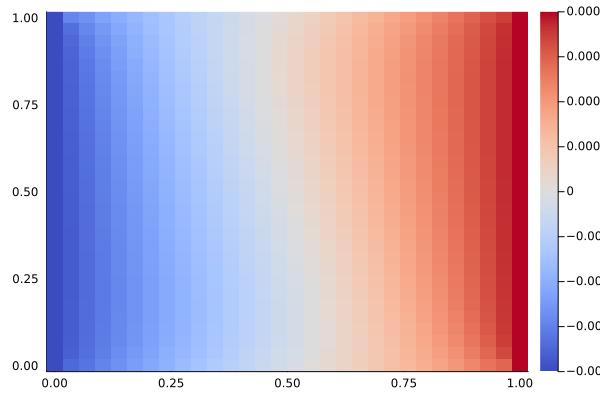

In [26]:
heatmap(x, y, a1', color = :coolwarm,)

In [27]:
a1[end,1]

9.999999999493375e-6

In [28]:
t[2]*0.5*1e-2

1.0e-5

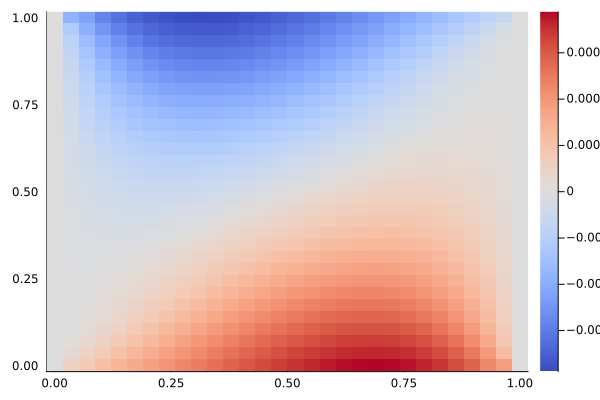

In [29]:
heatmap(x, y, a2', color = :coolwarm,)

In [30]:
a1x = 0.0*similar(a1)
a1y = 0.0*similar(a1)

a2x = 0.0*similar(a2)
a2y = 0.0*similar(a2)

    for j in 1:p.Ny
        for i in 1:p.Nx
            a1x[i,j] = Dx(a1,i,j,p)
            a1y[i,j] = Dy(a1,i,j,p)
            
            a2x[i,j] = Dx(a2,i,j,p)
            a2y[i,j] = Dy(a2,i,j,p)
        end
    end

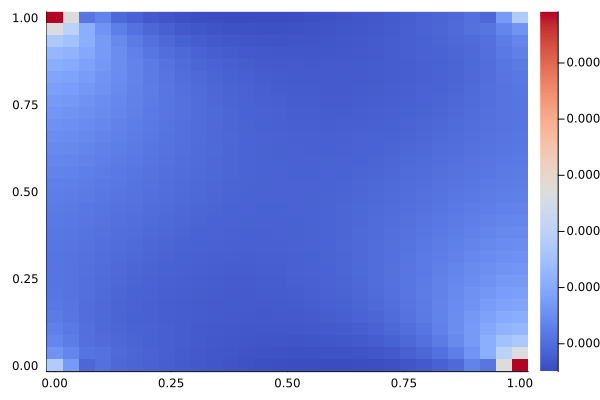

In [31]:
heatmap(x, y, a1x', color = :coolwarm,)

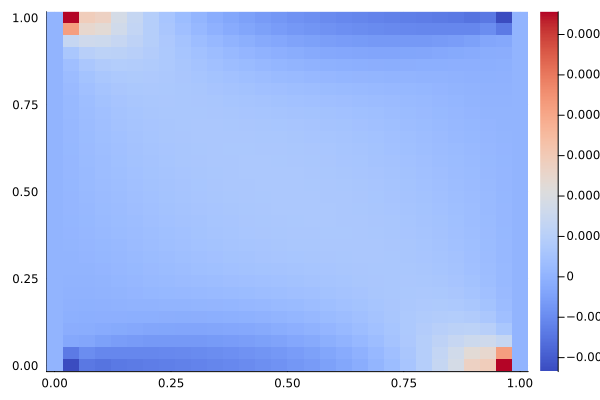

In [32]:
heatmap(x, y, a1y', color = :coolwarm,)

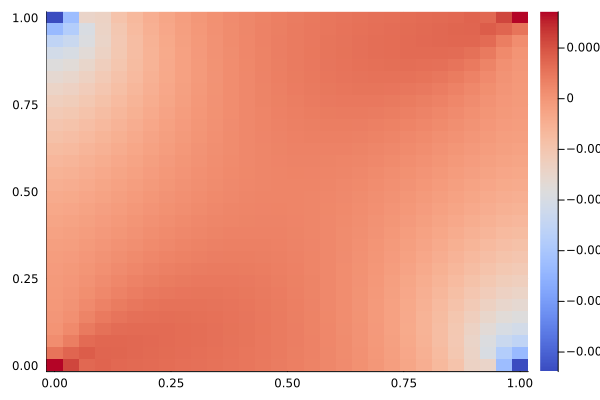

In [33]:
heatmap(x, y, a2x', color = :coolwarm,)

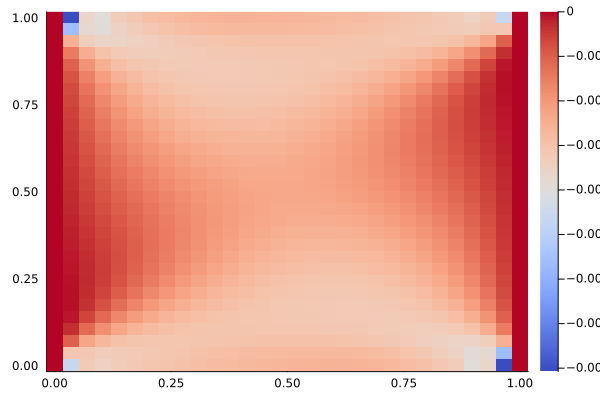

In [34]:
heatmap(x, y, a2y', color = :coolwarm,)

In [35]:
function DDx(x,f)
    Nx = length(x)
    Δx = x[2]-x[1]
    fx = 0.0*copy(f)
    fx[1,:] .= (f[2,:] .- f[1,:]) / Δx
    fx[Nx,:] .= (f[Nx,:] .- f[Nx-1,:]) / Δx
    for i in 2:Nx-1
        fx[i,:].= (f[i+1,:] .- f[i-1,:]) / (2Δx)
    end
    return fx
end

function DDy(y,f)
    Ny = length(y)
    Δy = y[2]-y[1]
    fy = 0.0*copy(f)
    fy[:,1] .= (f[:,2] .- f[:,1]) / Δy
    fy[:,Ny] .=  (f[:,Ny] .- f[:,Ny-1]) / Δy
    for j in 2:Ny-1
        fy[:,j] .= (f[:,j+1] .- f[:,j-1]) / (2Δy)
    end
    return fy
end

DDy (generic function with 1 method)

In [36]:
Da1x = DDx(x,a1)
Da1y = DDy(y,a1)

Da2x = DDx(x,a2)
Da2y = DDy(y,a2)

30×30 Matrix{Float64}:
  7.91989e-15  -3.24205e-16  -4.07638e-15  …  -2.18773e-16   2.41975e-16
 -1.16219e-5   -7.77585e-6   -2.56357e-6      -1.41896e-5   -2.01936e-5
 -8.13412e-6   -7.76154e-6   -5.62058e-6      -9.36629e-6   -9.04861e-6
 -8.71439e-6   -8.26966e-6   -6.68619e-6      -9.80681e-6   -9.9415e-6
 -8.18542e-6   -8.13622e-6   -7.33235e-6      -8.70285e-6   -8.21727e-6
 -7.97854e-6   -8.01295e-6   -7.59744e-6   …  -8.24365e-6   -7.79668e-6
 -7.72655e-6   -7.84174e-6   -7.70482e-6      -7.76397e-6   -7.27143e-6
 -7.52499e-6   -7.67879e-6   -7.71697e-6      -7.43984e-6   -6.97009e-6
 -7.34151e-6   -7.52325e-6   -7.68285e-6      -7.18985e-6   -6.73875e-6
 -7.17865e-6   -7.38011e-6   -7.62574e-6      -7.0152e-6    -6.59052e-6
 -7.03149e-6   -7.2496e-6    -7.56032e-6   …  -6.89684e-6   -6.49828e-6
 -6.89889e-6   -7.13248e-6   -7.49536e-6      -6.82595e-6   -6.45343e-6
 -6.78027e-6   -7.02951e-6   -7.43684e-6      -6.79379e-6   -6.44597e-6
  ⋮                                      

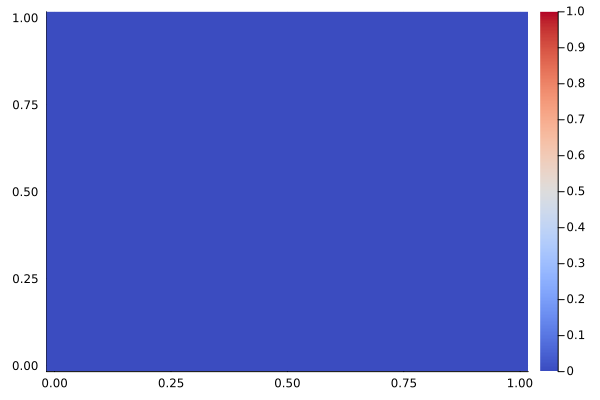

In [37]:
heatmap(x, y, (Da1x .-a1x)', color = :coolwarm,)

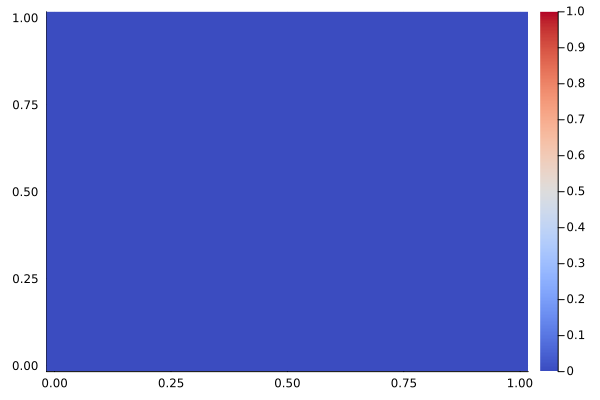

In [38]:
heatmap(x, y, (Da1y .-a1y)', color = :coolwarm,)

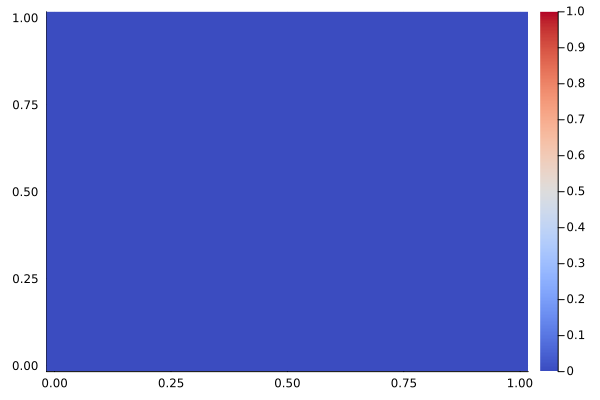

In [39]:
heatmap(x, y, (Da2x .-a2x)', color = :coolwarm,)

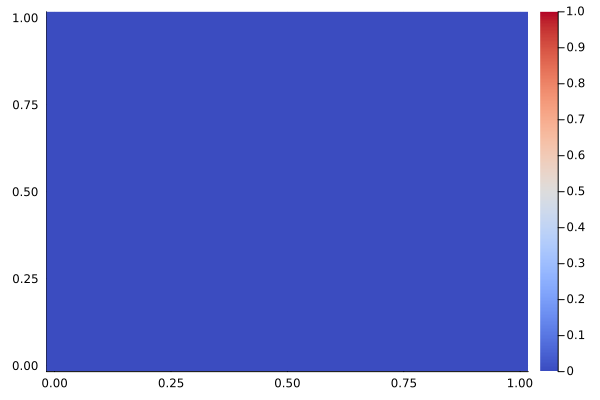

In [40]:
heatmap(x, y, (Da2y.-a2y)', color = :coolwarm,)